In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [3]:
# 1. Import the dataset
df = pd.read_csv("C:\\Users\\landg\\Downloads\\Stock_Prices.csv")

In [4]:
# 2. Explore the dataset
print(df.head())
print(df.info())
print(df.describe())

         Date   Close    Open    High     Low   Volume
0  2022-01-01  150.50  151.25  153.18  150.29  1551025
1  2022-01-02  150.36  150.84  151.59  150.05  1797917
2  2022-01-03  151.01  151.40  151.97  150.51  1300709
3  2022-01-04  152.53  152.93  154.67  152.21  1943026
4  2022-01-05  152.30  152.01  152.74  151.64  1906046
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    200 non-null    object 
 1   Close   200 non-null    float64
 2   Open    200 non-null    float64
 3   High    200 non-null    float64
 4   Low     200 non-null    float64
 5   Volume  200 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB
None
            Close        Open        High         Low        Volume
count  200.000000  200.000000  200.000000  200.000000  2.000000e+02
mean   142.083400  142.076100  143.341100  140.834850  1.506512e+06

In [5]:
# 3. Convert 'Date' to datetime format and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)


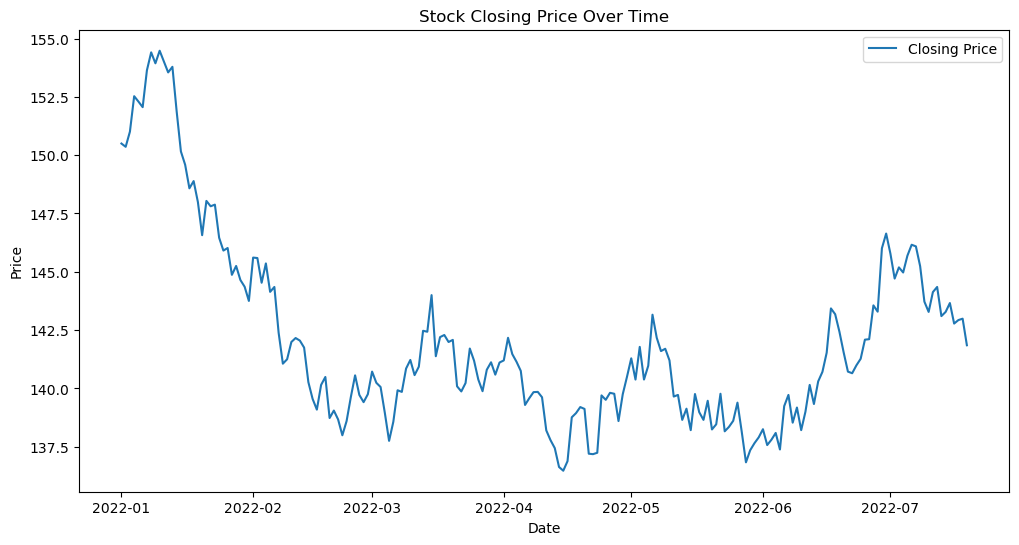

In [6]:
# 4. Plot line chart of Closing Price
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

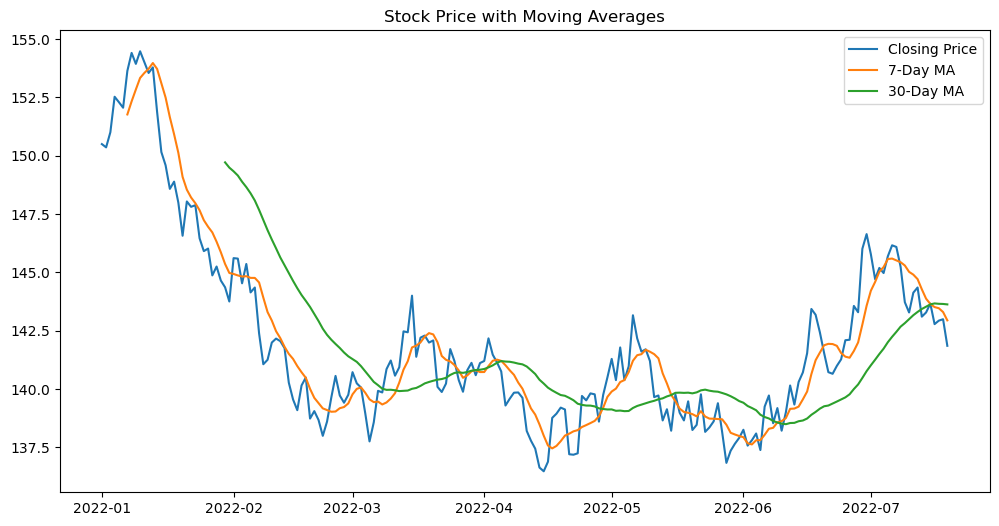

In [8]:
# 5. Calculate and plot moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price')
plt.plot(df['MA_7'], label='7-Day MA')
plt.plot(df['MA_30'], label='30-Day MA')
plt.title('Stock Price with Moving Averages')
plt.legend()
plt.show()


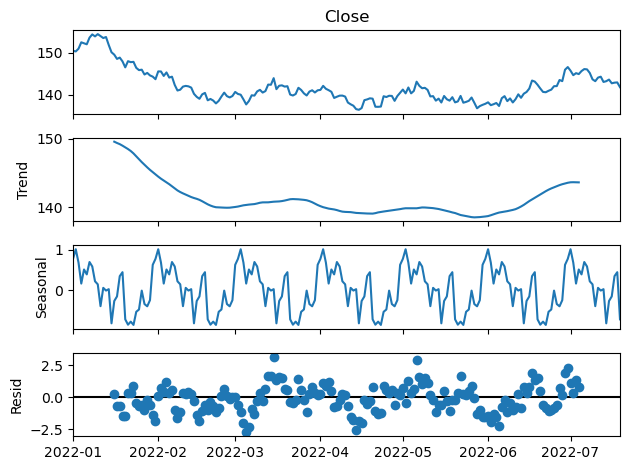

In [9]:
# 6. Seasonality analysis
result = seasonal_decompose(df['Close'], model='additive', period=30)
result.plot()
plt.show()

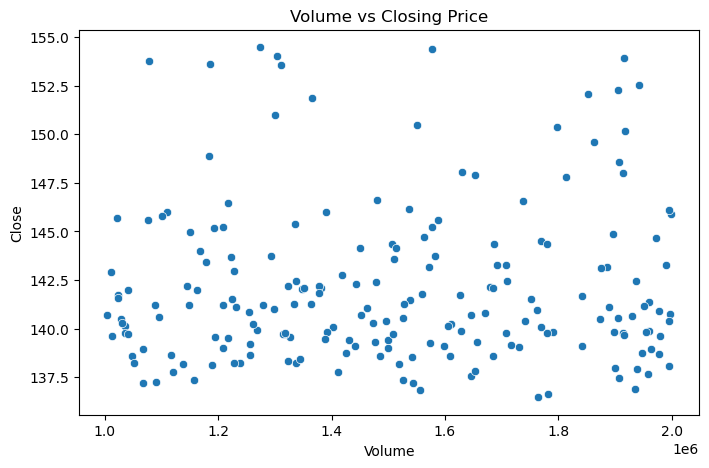

Correlation Matrix:
           Close   Volume
Close   1.00000  0.04001
Volume  0.04001  1.00000


In [11]:
# 7. Correlation between price and volume
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Volume', y='Close', data=df)
plt.title('Volume vs Closing Price')
plt.show()
corr = df[['Close', 'Volume']].corr()
print("Correlation Matrix:\n", corr)

In [12]:
# 8. Forecasting using ARIMA
# Split into train and test
train = df['Close'][:-30]
test = df['Close'][-30:]

In [13]:
# Fit ARIMA model
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()
forecast = model_fit.forecast(steps=30)


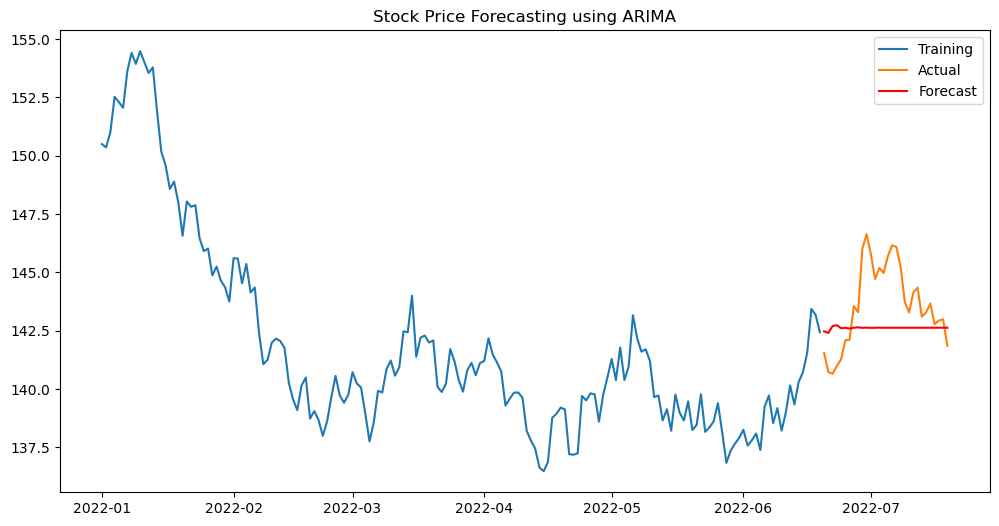

In [14]:
# Plot forecast
plt.figure(figsize=(12, 6))
plt.plot(train, label='Training')
plt.plot(test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title('Stock Price Forecasting using ARIMA')
plt.legend()
plt.show()